In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
sns.set()

# 1. Force the file path verification right inside the cell
import os
print(f"Current Directory: {os.getcwd()}")
print(f"Files Python can see: {os.listdir('.')}")

try:
    # 2. Re-read the fresh data file
    raw_data = pd.read_csv('1.03.+Dummies.csv')
    data = raw_data.copy()
    data['Attendance'] = data['Attendance'].map({'Yes': 1, 'No': 0})
    
    # 3. Re-scramble the deck to fix autocorrelation
    data_shuffled = data.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # 4. Declare your clean target and multi-variables
    y = data_shuffled['GPA']
    x1 = data_shuffled[['SAT', 'Attendance']]
    
    # 5. Add the structural constant baseline
    x = sm.add_constant(x1)
    results = sm.OLS(y, x).fit()
    print("--- SUCCESS: Variables loaded into active RAM memory! ---")
    
except Exception as e:
    print(f"🛑 SYSTEM BLOCKED AT STARTUP: {e}")
    print("Verify that '1.03.+Dummies.csv' is sitting in the file list printed above!")

Current Directory: C:\Users\Waheed\Desktop\AI stuff\stats-and-ai-learning
Files Python can see: ['.git', '.gitignore', '.ipynb_checkpoints', '1.01.Simple linear regression.csv', '1.02.+Multiple+linear+regression.csv', '1.03.+Dummies.csv', 'AI Stuff revamped.ipynb', 'anaconda_projects', 'Dummy+Variables.ipynb', 'Dummy+variables_with_comments.ipynb', 'Multiple+linear+regression+and+Adjusted+R-squared_.ipynb', 'Multiple+linear+regression+and+Adjusted+R-squared_with_comments.ipynb', 'Multiple+Linear+Regression+Exercise+Solution.ipynb', 'Multiple+Linear+Regression+Exercise.ipynb', 'Multiple+Linear+Regression+with+Dummies+Exercise+Solution.ipynb', 'Multiple+Linear+Regression+with+Dummies+Exercise.ipynb', 'real_estate_price_size.csv', 'real_estate_price_size_year.csv', 'real_estate_price_size_year_view.csv', 'Simple+Linear+Regression+Exercise+Solution.ipynb', 'Simple+Linear+Regression+Exercise.ipynb', 'Simple+Linear+Regression+with+sklearn+-+Exercise+Solution.ipynb', 'Simple+Linear+Regression

In [2]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     52.70
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           2.19e-15
Time:                        01:33:22   Log-Likelihood:                 25.798
No. Observations:                  84   AIC:                            -45.60
Df Residuals:                      81   BIC:                            -38.30
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6439      0.358      1.797      0.076      -0.069       1.357
SAT            0.0014      0.000      7.141      0.000       0.001       0.002
Attendance     0.2226      0.041      5.451      0.000       0.141       0.304
==============================================================================
Omnibus:                       19.560   Durbin-Watson:                   2.135
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.189
Skew:                          -1.028   Prob(JB):                     1.25e-06
Kurtosis:                       4.881   Cond. No.                     3.35e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.35e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [3]:
raw_data=pd.read_csv('1.03.+Dummies.csv')

In [4]:
raw_data

,SAT,GPA,Attendance
0,1714,2.40,No
1,1664,2.52,No
2,1760,2.54,No
3,1685,2.74,No
4,1693,2.83,No
...,...,...,...
79,1936,3.71,Yes
80,1810,3.71,Yes
81,1987,3.73,No
82,1962,3.76,Yes


In [5]:
data = raw_data.copy()

In [6]:
data['Attendance'] = data['Attendance'].map({'Yes': 1, 'No': 0})

In [7]:
data

,SAT,GPA,Attendance
0,1714,2.40,0
1,1664,2.52,0
2,1760,2.54,0
3,1685,2.74,0
4,1693,2.83,0
...,...,...,...
79,1936,3.71,1
80,1810,3.71,1
81,1987,3.73,0
82,1962,3.76,1


In [8]:
data.describe()

,SAT,GPA,Attendance
count,84.000000,84.000000,84.000000
mean,1845.273810,3.330238,0.464286
std,104.530661,0.271617,0.501718
min,1634.000000,2.400000,0.000000
25%,1772.000000,3.190000,0.000000
50%,1846.000000,3.380000,0.000000
75%,1934.000000,3.502500,1.000000
max,2050.000000,3.810000,1.000000


In [9]:
## REGRESSION

In [10]:
y = data['GPA']
x1 = data[['SAT', 'Attendance']]

In [11]:
x = sm.add_constant(x1)
results = sm.OLS(y,x).fit()

In [12]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     52.70
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           2.19e-15
Time:                        01:33:22   Log-Likelihood:                 25.798
No. Observations:                  84   AIC:                            -45.60
Df Residuals:                      81   BIC:                            -38.30
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6439      0.358      1.797      0.076      -0.069       1.357
SAT            0.0014      0.000      7.141      0.000       0.001       0.002
Attendance     0.2226      0.041      5.451      0.000       0.141       0.304
==============================================================================
Omnibus:                       19.560   Durbin-Watson:                   1.009
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.189
Skew:                          -1.028   Prob(JB):                     1.25e-06
Kurtosis:                       4.881   Cond. No.                     3.35e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.35e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [13]:
## Doing a shuffle in the table so the table shows the "Yes" and "No's" in a random order rather than the No's at the top and the Yes's at the bottom.
## By doing this I hope my Durbin_Watson shoots up so my model fits the data better

In [14]:
data_shuffled = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [15]:
y = data_shuffled['GPA']
x1 = data_shuffled[['SAT', 'Attendance']]

In [16]:
x = sm.add_constant(x1)
results = sm.OLS(y,x).fit()

In [17]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     52.70
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           2.19e-15
Time:                        01:33:22   Log-Likelihood:                 25.798
No. Observations:                  84   AIC:                            -45.60
Df Residuals:                      81   BIC:                            -38.30
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6439      0.358      1.797      0.076      -0.069       1.357
SAT            0.0014      0.000      7.141      0.000       0.001       0.002
Attendance     0.2226      0.041      5.451      0.000       0.141       0.304
==============================================================================
Omnibus:                       19.560   Durbin-Watson:                   2.135
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.189
Skew:                          -1.028   Prob(JB):                     1.25e-06
Kurtosis:                       4.881   Cond. No.                     3.35e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.35e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [18]:
## Saw a jump in Durbin-Watson which makes our model more fitting for the data.

In [19]:
## Next step is to plot the data on the graph with the new categorical dummy values to see how our model looks like.

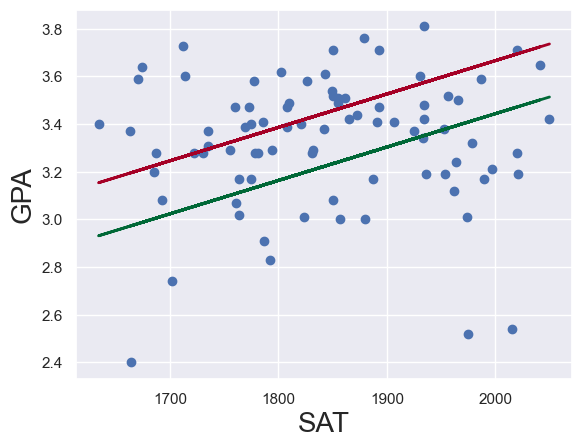

In [20]:
plt.scatter(data['SAT'],y)
yhat_no = 0.6439 + 0.0014*data['SAT']
yhat_yes = 0.8665 + 0.0014*data['SAT']
fig = plt.plot(data['SAT'],yhat_no, lw = 2, c='#006837')
fig = plt.plot(data['SAT'],yhat_yes, lw = 2, c='#a50026')
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()

In [21]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     52.70
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           2.19e-15
Time:                        01:33:22   Log-Likelihood:                 25.798
No. Observations:                  84   AIC:                            -45.60
Df Residuals:                      81   BIC:                            -38.30
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6439      0.358      1.797      0.076      -0.069       1.357
SAT            0.0014      0.000      7.141      0.000       0.001       0.002
Attendance     0.2226      0.041      5.451      0.000       0.141       0.304
==============================================================================
Omnibus:                       19.560   Durbin-Watson:                   2.135
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.189
Skew:                          -1.028   Prob(JB):                     1.25e-06
Kurtosis:                       4.881   Cond. No.                     3.35e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.35e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [22]:
## Doing an exercise to see if I understand the concept or not.
## Check the Multiple+Linear+Regression+with+Dummies+Exercise to see the inputs.

In [23]:
# Multiple Linear Regression with Dummies - Exercise

In [24]:
raw_data = pd.read_csv('real_estate_price_size_year_view.csv')

In [25]:
data = raw_data.copy()

In [26]:
data

,price,size,year,view
0,234314.144,643.09,2015,No sea view
1,228581.528,656.22,2009,No sea view
2,281626.336,487.29,2018,Sea view
3,401255.608,1504.75,2015,No sea view
4,458674.256,1275.46,2009,Sea view
...,...,...,...,...
95,252460.400,549.80,2009,Sea view
96,310522.592,1037.44,2009,No sea view
97,383635.568,1504.75,2006,No sea view
98,225145.248,648.29,2015,No sea view


In [27]:
data['view'] = data['view'].map({'No sea view': 0, 'Sea view': 1})

In [28]:
data

,price,size,year,view
0,234314.144,643.09,2015,0
1,228581.528,656.22,2009,0
2,281626.336,487.29,2018,1
3,401255.608,1504.75,2015,0
4,458674.256,1275.46,2009,1
...,...,...,...,...
95,252460.400,549.80,2009,1
96,310522.592,1037.44,2009,0
97,383635.568,1504.75,2006,0
98,225145.248,648.29,2015,0


In [29]:
data.describe()

,price,size,year,view
count,100.000000,100.000000,100.000000,100.000000
mean,292289.470160,853.024200,2012.600000,0.490000
std,77051.727525,297.941951,4.729021,0.502418
min,154282.128000,479.750000,2006.000000,0.000000
25%,234280.148000,643.330000,2009.000000,0.000000
50%,280590.716000,696.405000,2015.000000,0.000000
75%,335723.696000,1029.322500,2018.000000,1.000000
max,500681.128000,1842.510000,2018.000000,1.000000


In [30]:
## Fixing the NaN bug

In [31]:
data = raw_data.copy()

In [32]:
data['view']=data['view'].map({'No sea view' :0, 'Sea view': 1})

In [33]:
data

,price,size,year,view
0,234314.144,643.09,2015,0
1,228581.528,656.22,2009,0
2,281626.336,487.29,2018,1
3,401255.608,1504.75,2015,0
4,458674.256,1275.46,2009,1
...,...,...,...,...
95,252460.400,549.80,2009,1
96,310522.592,1037.44,2009,0
97,383635.568,1504.75,2006,0
98,225145.248,648.29,2015,0


In [34]:
y = data['price']

In [35]:
x1 = data[['size','year','view']]

In [36]:
x = sm.add_constant(x1)

In [37]:
results = sm.OLS(y,x).fit()

In [38]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     335.2
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           1.02e-50
Time:                        01:33:22   Log-Likelihood:                -1144.6
No. Observations:                 100   AIC:                             2297.
Df Residuals:                      96   BIC:                             2308.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5.398e+06   9.94e+05     -5.431      0.000   -7.37e+06   -3.43e+06
size         223.0316      7.838     28.455      0.000     207.473     238.590
year        2718.9489    493.502      5.510      0.000    1739.356    3698.542
view        5.673e+04   4627.695     12.258      0.000    4.75e+04    6.59e+04
==============================================================================
Omnibus:                       29.224   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               64.957
Skew:                           1.088   Prob(JB):                     7.85e-15
Kurtosis:                       6.295   Cond. No.                     9.42e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.42e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [39]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     335.2
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           1.02e-50
Time:                        01:33:22   Log-Likelihood:                -1144.6
No. Observations:                 100   AIC:                             2297.
Df Residuals:                      96   BIC:                             2308.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5.398e+06   9.94e+05     -5.431      0.000   -7.37e+06   -3.43e+06
size         223.0316      7.838     28.455      0.000     207.473     238.590
year        2718.9489    493.502      5.510      0.000    1739.356    3698.542
view        5.673e+04   4627.695     12.258      0.000    4.75e+04    6.59e+04
==============================================================================
Omnibus:                       29.224   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               64.957
Skew:                           1.088   Prob(JB):                     7.85e-15
Kurtosis:                       6.295   Cond. No.                     9.42e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.42e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [40]:
## Transitioning into SKlearn toolkit. Starting with Simple linear regression.

In [41]:
data = pd.read_csv('1.01.Simple linear regression.csv')
data.head()

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


In [42]:
x = data['SAT']
y = data['GPA']
## GPA = Target, SAT = Feature. (New alternative names for SKlearn only)

In [43]:
x.shape

(84,)

In [44]:
y.shape

(84,)

In [45]:
##Since we got the error down below for trying to reg.fit(x,y) as a 1d array and Sklearn is expecting 2d arrays, we add the following code:

In [46]:
x_matrix= x.values.reshape(-1,1)
x_matrix.shape ## We just change the dimensionality from a 1d object into 2d object

(84, 1)

In [47]:
## Next step is regression.

In [48]:
reg = LinearRegression()

In [49]:
reg.fit(x_matrix,y) ##Input is very important, we always put x first which is the input then y which is the target.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
print(f"The Intercept Baseline: {reg.intercept_}")
print(f"The SAT Multiplier Slope: {reg.coef_}")

The Intercept Baseline: 0.2750402996602781
The SAT Multiplier Slope: [0.00165569]


In [51]:
reg.score(x_matrix,y)

0.40600391479679754

In [52]:
reg.coef_

array([0.00165569])

In [53]:
## Making predictions using SKlearn

In [54]:
##Fixing the above error into tricking SKlearn that I'm having a 2d array instead of 1d array by using this:
reg.predict([[1740]]) ## By using double brackets the engine will think this is a 2d array instead of 1d.

array([3.15593751])

In [55]:
## Feeding SKlearn a data frame:
new_data=pd.DataFrame(data=[1740,1760], columns=['SAT'])
new_data

,SAT
0,1740
1,1760


In [56]:
reg.predict(new_data)

d:\Users\Waheed\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([3.15593751, 3.18905127])

In [57]:
new_data['Predicted_GPA']= reg.predict(new_data)
new_data

d:\Users\Waheed\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


,SAT,Predicted_GPA
0,1740,3.155938
1,1760,3.189051


In [58]:
## Doing the simple linear regression exercise with SKlearn now.

In [59]:
data=pd.read_csv('real_estate_price_size.csv')

In [60]:
data.head()

,price,size
0,234314.144,643.09
1,228581.528,656.22
2,281626.336,487.29
3,401255.608,1504.75
4,458674.256,1275.46


In [61]:
x = data['size']
y = data['price']

In [62]:
x.shape

(100,)

In [63]:
y.shape

(100,)

In [64]:
x_matrix = x.values.reshape(-1,1)

In [65]:
x_matrix.shape

(100, 1)

In [66]:
y.shape

(100,)

In [67]:
reg = LinearRegression()

In [68]:
reg.fit(x_matrix,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
reg.coef_

array([223.17874259])

In [70]:
reg.intercept_

np.float64(101912.60180122912)

In [71]:
reg.predict([[750]])

array([269296.65874718])

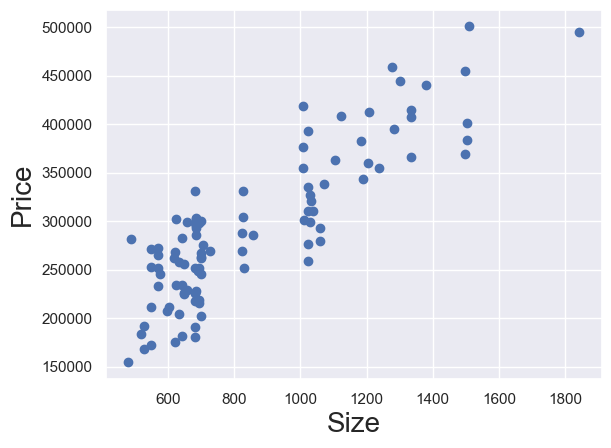

In [72]:
plt.scatter(x,y)
plt.xlabel('Size', fontsize=20)
plt.ylabel('Price', fontsize=20)
plt.show()

In [73]:
reg.score(x_matrix,y) ##Calculating R_Squared

0.7447391865847587

In [74]:
## Exercise ended.

In [75]:
## Multiple linear regression starts.

In [76]:
data = pd.read_csv('1.02.+Multiple+linear+regression.csv')

In [77]:
data.head()

,SAT,"Rand 1,2,3",GPA
0,1714,1,2.40
1,1664,3,2.52
2,1760,3,2.54
3,1685,3,2.74
4,1693,2,2.83


In [78]:
data.describe() ## Rand 1,2,3 is just a random variable assigned to each sample

,SAT,"Rand 1,2,3",GPA
count,84.000000,84.000000,84.000000
mean,1845.273810,2.059524,3.330238
std,104.530661,0.855192,0.271617
min,1634.000000,1.000000,2.400000
25%,1772.000000,1.000000,3.190000
50%,1846.000000,2.000000,3.380000
75%,1934.000000,3.000000,3.502500
max,2050.000000,3.000000,3.810000


In [79]:
x = data [['SAT', 'Rand 1,2,3']]

In [80]:
y = data ['GPA']

In [81]:
reg = LinearRegression()
reg.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [82]:
reg.coef_ ##It responds to the way that we fed it: SAT was first so it spit out 0.00165354, and the Rand 1,2,3 variable is next so it spit out -0.00826982

array([ 0.00165354, -0.00826982])

In [83]:
reg.intercept_

np.float64(0.29603261264909353)

In [84]:
reg.score(x,y)

0.4066811952814282

## Forumula for Adjusted R^2
$R^2_{adj.} = 1 - (1-R^2)*\frac{n-1}{n-p-1}$

In [85]:
## n stands for the number of observations and p stands for the predictors

In [86]:
x.shape ## n = 84 and p = 2

(84, 2)

In [87]:
r2 = reg.score(x,y)

n = x.shape[0]
p = x.shape[1]

adjusted_r2=1-(1-r2)*(n-1)/(n-p-1)
adjusted_r2

0.39203134825134

In [88]:
## Doing the exercise for multiple linear regression adjust r^2 with sklearn

In [89]:
data = pd.read_csv('1.02.+Multiple+linear+regression.csv')

In [90]:
data.head()

,SAT,"Rand 1,2,3",GPA
0,1714,1,2.40
1,1664,3,2.52
2,1760,3,2.54
3,1685,3,2.74
4,1693,2,2.83


In [91]:
data.describe()

,SAT,"Rand 1,2,3",GPA
count,84.000000,84.000000,84.000000
mean,1845.273810,2.059524,3.330238
std,104.530661,0.855192,0.271617
min,1634.000000,1.000000,2.400000
25%,1772.000000,1.000000,3.190000
50%,1846.000000,2.000000,3.380000
75%,1934.000000,3.000000,3.502500
max,2050.000000,3.000000,3.810000


In [92]:
x = data[['SAT', 'Rand 1,2,3']]

In [93]:
y = data['GPA']

In [94]:
reg = LinearRegression()
reg.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [95]:
reg.coef_

array([ 0.00165354, -0.00826982])

In [96]:
reg.intercept_

np.float64(0.29603261264909353)

In [97]:
reg.score(x,y)

0.4066811952814282

In [98]:
x.shape

(84, 2)

In [99]:
r2 = reg.score(x,y)
n = x.shape[0]
p = x.shape[1]

adjusted_r2= 1-(1-r2)*(n-1)/(n-p-1)

In [100]:
adjusted_r2

0.39203134825134

In [101]:
adjusted_r2

0.39203134825134

In [102]:
## Trying f_regression as a method using sklearn

In [103]:
f_regression(x,y)

(array([56.04804786,  0.17558437]), array([7.19951844e-11, 6.76291372e-01]))

In [104]:
## Since the p-value of the F- stat equals the p-value of the only independent variable,
## we're assigning a variable for the p-value and storing the p-value string in the above array in it

In [105]:
p_values=f_regression(x,y)[1]

In [106]:
p_values

array([7.19951844e-11, 6.76291372e-01])

In [107]:
p_values.round(3)

array([0.   , 0.676])

In [108]:
## The first element refers to the first column of x which is 'SAT' and the second one is 'Rand 1,2,3' in our example

## Creating a summary table.

In [109]:
reg_summary = pd.DataFrame(data=x.columns.values, columns=['Features'])

In [110]:
reg_summary

,Features
0,SAT
1,"Rand 1,2,3"


In [111]:
reg_summary ['Coefficients'] = reg.coef_

In [112]:
reg_summary ['p-values'] = p_values.round(3)

In [113]:
reg_summary

,Features,Coefficients,p-values
0,SAT,0.001654,0.000
1,"Rand 1,2,3",-0.008270,0.676


## Standardizing our data

In [114]:
## Imported the library in the first cell.

In [115]:
scaler = StandardScaler()

In [116]:
scaler.fit(x)

,copy,True
,with_mean,True
,with_std,True


In [117]:
x_scaled = scaler.transform(x)

In [120]:
x_scaled

array([[-1.26338288, -1.24637147],
       [-1.74458431,  1.10632974],
       [-0.82067757,  1.10632974],
       [-1.54247971,  1.10632974],
       [-1.46548748, -0.07002087],
       [-1.68684014, -1.24637147],
       [-0.78218146, -0.07002087],
       [-0.78218146, -1.24637147],
       [-0.51270866, -0.07002087],
       [ 0.04548499,  1.10632974],
       [-1.06127829,  1.10632974],
       [-0.67631715, -0.07002087],
       [-1.06127829, -1.24637147],
       [-1.28263094,  1.10632974],
       [-0.6955652 , -0.07002087],
       [ 0.25721362, -0.07002087],
       [-0.86879772,  1.10632974],
       [-1.64834403, -0.07002087],
       [-0.03150724,  1.10632974],
       [-0.57045283,  1.10632974],
       [-0.81105355,  1.10632974],
       [-1.18639066,  1.10632974],
       [-1.75420834,  1.10632974],
       [-1.52323165, -1.24637147],
       [ 1.23886453, -1.24637147],
       [-0.18549169, -1.24637147],
       [-0.5608288 , -1.24637147],
       [-0.23361183,  1.10632974],
       [ 1.68156984,

In [121]:
reg = LinearRegression()

In [122]:
reg.fit(x_scaled,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [123]:
reg.coef_

array([ 0.17181389, -0.00703007])

In [124]:
reg.intercept_

np.float64(3.330238095238095)

In [130]:
reg_summary = pd.DataFrame([['Bias'],['SAT'],['Rand 1,2,3']], columns =['Features'])
reg_summary['Weights']=reg.intercept_,reg.coef_[0], reg.coef_[1]

In [131]:
reg_summary

,Features,Weights
0,Bias,3.330238
1,SAT,0.171814
2,"Rand 1,2,3",-0.007030


## Making predictions with the sandardized coefficients (weights)

In [132]:
new_data = pd.DataFrame(data=[[1700,2],[1800,1]], columns = ['SAT','Rand 1,2,3'])
new_data

,SAT,"Rand 1,2,3"
0,1700,2
1,1800,1


In [133]:
reg.predict(new_data)

d:\Users\Waheed\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([295.39979563, 312.58821497])

In [134]:
new_data_scaled = scaler.transform(new_data)
new_data_scaled

array([[-1.39811928, -0.07002087],
       [-0.43571643, -1.24637147]])

In [135]:
reg.predict(new_data_scaled)

array([3.09051403, 3.26413803])

## What if we removed the 'Random 1,2,3' variable?

In [136]:
reg_simple = LinearRegression()

In [138]:
x_simple_matrix = x_scaled[:,0].reshape(-1,1)

In [139]:
reg_simple.fit(x_simple_matrix,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [141]:
reg_simple.predict(new_data_scaled[:,0].reshape(-1,1))

array([3.08970998, 3.25527879])

## Train - Test Split

In [142]:
## We're exploring how to train the model and test it by doing a split

In [145]:
a = np.arange(1,101)
a

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [182]:
b = np.arange(501,601)
b

array([501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513,
       514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 526,
       527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538, 539,
       540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 552,
       553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565,
       566, 567, 568, 569, 570, 571, 572, 573, 574, 575, 576, 577, 578,
       579, 580, 581, 582, 583, 584, 585, 586, 587, 588, 589, 590, 591,
       592, 593, 594, 595, 596, 597, 598, 599, 600])

In [183]:
train_test_split(a)

[array([ 38,  66,   2,   9,  57,  60,  70,  51,  14,  37,  13,  41,  59,
         72,  64,  91,  29,   4,  39,  98,  54,  90,  31,  28,  94,   5,
         15,  80,  46,  88,   1,  17, 100,  26,  18,  58,  49,  69,  50,
         95,  89,  67,  43,  19,  73,  12,  22,  63,  83,  61,  30,  86,
         34,  33,  99,  23,  42,  65,  27,  35,   3,  77,  76,  32,   7,
         40,  48,  44,  55,  75,  93,  81,   8,  78,  47]),
 array([82, 56, 68, 62, 16, 85, 20, 71, 11, 21, 92, 87, 10, 74, 53, 79, 36,
         6, 84, 52, 25, 96, 97, 24, 45])]

In [184]:
a_train, a_test, b_train, b_test = train_test_split(a, b, test_size=0.2, random_state=365)

In [176]:
a_train.shape, a_test.shape

((80,), (20,))

In [208]:
a_train

array([  1,   2,   3,   4,   6,   7,   8,  10,  11,  12,  13,  15,  16,
        17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,
        30,  31,  32,  34,  35,  37,  38,  39,  40,  41,  42,  43,  44,
        45,  47,  48,  49,  50,  51,  53,  54,  55,  57,  58,  59,  60,
        62,  63,  64,  65,  66,  68,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  82,  83,  86,  87,  88,  90,  91,  92,  94,  95,
        99, 100])

In [205]:
a_test

array([ 5,  9, 14, 33, 36, 46, 52, 56, 61, 67, 69, 70, 81, 84, 85, 89, 93,
       96, 97, 98])

In [191]:
print(f"Rows inside array 'a': {len(a)}")
print(f"Rows inside array 'b': {len(b)}")

Rows inside array 'a': 100
Rows inside array 'b': 100


In [202]:
b_train.shape, b_test.shape

((80,), (20,))

In [203]:
b_train

array([525, 532, 599, 573, 591, 566, 503, 559, 594, 501, 508, 515, 590,
       554, 531, 520, 577, 582, 530, 535, 595, 542, 538, 507, 511, 550,
       521, 548, 502, 517, 510, 558, 568, 543, 541, 516, 588, 572, 579,
       600, 580, 539, 524, 586, 522, 523, 562, 576, 518, 547, 555, 526,
       560, 519, 571, 564, 551, 563, 565, 528, 512, 578, 513, 544, 575,
       587, 540, 504, 529, 549, 537, 557, 527, 574, 506, 545, 592, 534,
       553, 583])

In [204]:
b_test

array([509, 569, 581, 556, 533, 593, 584, 561, 546, 589, 585, 567, 597,
       505, 570, 536, 598, 596, 514, 552])

## Practical real life example with new data.

In [210]:
raw_data=pd.read_csv('1.04.+Real-life+example.csv')
raw_data.head()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


In [212]:
raw_data.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000,4345
unique,7,NaN,6,NaN,NaN,4,2,NaN,312
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN,199
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058,NaN
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


In [213]:
data = raw_data.drop(['Model'], axis=1)

In [215]:
data.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000


## Dealing with missing values

In [219]:
data.isnull().sum() ## We see that some values have 4345 and the others have less, so we are checking for the missing values and extracting them
## True stands for missing value, while false is an available one (False is 0, True is 1)

Brand             0
Price           172
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
dtype: int64

In [220]:
data_no_mv = data.dropna(axis=0)

In [221]:
data_no_mv.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,4025,4025.000000,4025,4025.000000,4025.000000,4025,4025,4025.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,880,NaN,1534,NaN,NaN,1861,3654,NaN
mean,NaN,19552.308065,NaN,163.572174,2.764586,NaN,NaN,2006.379627
std,NaN,25815.734988,NaN,103.394703,4.935941,NaN,NaN,6.695595
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6999.000000,NaN,90.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11500.000000,NaN,158.000000,2.200000,NaN,NaN,2007.000000
75%,NaN,21900.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000


## Dealing with outliers, looking at price above, it has a lot of outliers, maximum is 300k while minimum is 600. So we're excluding the 1% so our regression looks better

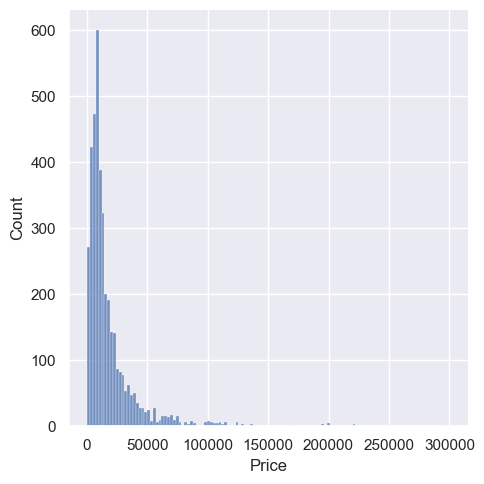

In [225]:
sns.displot(data_no_mv['Price'])

In [227]:
q = data_no_mv['Price'].quantile(0.99) ##Getting the 99th percentile and keep the data below it (Excluding the top 1% percentile which is 100%)
data_1 = data_no_mv[data_no_mv['Price']<q]
data_1.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,3984,3984.000000,3984,3984.000000,3984.000000,3984,3984,3984.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,880,NaN,1528,NaN,NaN,1853,3613,NaN
mean,NaN,17837.117460,NaN,165.116466,2.743770,NaN,NaN,2006.292922
std,NaN,18976.268315,NaN,102.766126,4.956057,NaN,NaN,6.672745
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6980.000000,NaN,93.000000,1.800000,NaN,NaN,2002.750000
50%,NaN,11400.000000,NaN,160.000000,2.200000,NaN,NaN,2007.000000
75%,NaN,21000.000000,NaN,230.000000,3.000000,NaN,NaN,2011.000000


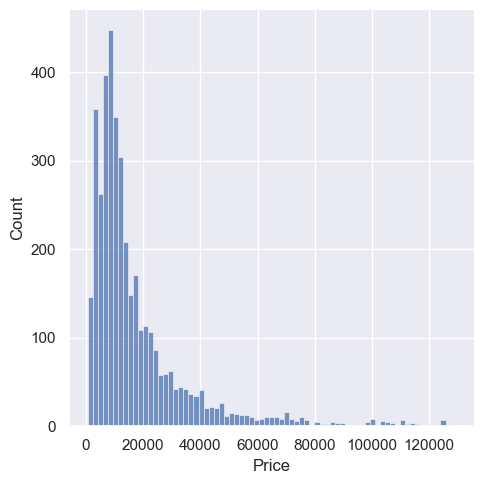

In [228]:
sns.displot(data_1['Price'])